# Unit 3.2 實作練習 — 決策樹 / 最近鄰 / 混淆矩陣

421104 Artificial Intelligence for Enterprises · Session 4 2026

對應 Canvas 頁面:
- **3.2.1** 使用合成數據的決策樹(評論框要貼 Q2 回答)
- **3.2.2** 使用合成數據的最近鄰(只需查看,不用貼)
- **3.2.4** 使用合成數據的混淆矩陣(**必修投寄**,貼文數字出自本 notebook)

由上而下逐格執行即可(Cell → Run All 也行)。每格上方的說明寫了預期輸出,跑完對一下。

## 一、3.2.1 決策樹:重現頁面練習

先照頁面步驟二訓練決策樹,然後跑五個測試點,並印出樹學到的結構。

**預期**:前四點輸出 0;`(0.6, 0.75)` 輸出 **1**(頁面寫 gives 0 是筆誤,與原始規則 X1>0.5 且 X2>0.5 → 1 對照即知);樹結構只有一刀 `X1 <= 0.5`,X2 沒被使用。

In [1]:
from sklearn import tree

base_X = [[0.1,0.4],[0.2,0.4],[0.15,0.3],[0.3,0.2],[0.4,0.4],
          [0.6,0.1],[0.7,0.9],[0.9,0.8],[0.6,0.1],[0.7,0.2],[0.9,0.15]]
base_Y = [0,0,0,0,0,1,1,1,1,1,1]

clf = tree.DecisionTreeClassifier(random_state=0).fit(base_X, base_Y)

for p in [[0.3,0.75],[0.4,0.75],[0.4,1],[0.5,1],[0.6,0.75]]:
    print(p, '->', clf.predict([p])[0])

print()
print(tree.export_text(clf, feature_names=['X1','X2']))

[0.3, 0.75] -> 0
[0.4, 0.75] -> 0
[0.4, 1] -> 0
[0.5, 1] -> 0
[0.6, 0.75] -> 1

|--- X1 <= 0.50
|   |--- class: 0
|--- X1 >  0.50
|   |--- class: 1



把訓練資料與那一刀畫出來,看清楚為什麼 X2 消失、以及左上象限完全沒有樣本:

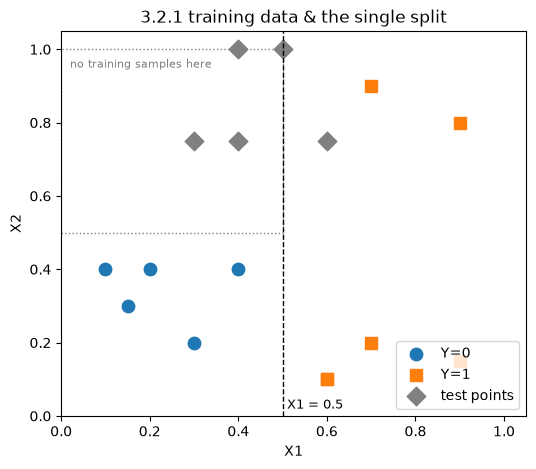

In [2]:
import matplotlib.pyplot as plt
import numpy as np

Xa = np.array(base_X); Ya = np.array(base_Y)
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(Xa[Ya==0,0], Xa[Ya==0,1], s=80, label='Y=0')
ax.scatter(Xa[Ya==1,0], Xa[Ya==1,1], s=80, marker='s', label='Y=1')
tests = np.array([[0.3,0.75],[0.4,0.75],[0.4,1],[0.5,1],[0.6,0.75]])
ax.scatter(tests[:,0], tests[:,1], s=90, marker='D', c='gray', label='test points')
ax.axvline(0.5, ls='--', c='k', lw=1)
ax.text(0.51, 0.02, 'X1 = 0.5', fontsize=9)
ax.add_patch(plt.Rectangle((0,0.5), 0.5, 0.5, fill=False, ls=':', ec='gray'))
ax.text(0.02, 0.95, 'no training samples here', fontsize=8, color='gray')
ax.set_xlabel('X1'); ax.set_ylabel('X2'); ax.set_xlim(0,1.05); ax.set_ylim(0,1.05)
ax.legend(loc='lower right'); ax.set_title('3.2.1 training data & the single split')
plt.show()

### 實驗 1:補左上象限樣本(對應 Q2 第 1 點)

同一批補點,標籤定 1 或定 0,決定 X2 會不會被用到。
**預期**:1a 樹變兩層(先切 X2 再切 X1);1b 樹仍只有 X1 一刀——此時這是對的,X2 真的無關。

In [3]:
extra = [[0.1,0.7],[0.2,0.9],[0.3,0.6],[0.4,0.8]]

clf_1a = tree.DecisionTreeClassifier(random_state=0).fit(base_X + extra, base_Y + [1,1,1,1])
print('1a: 補點標成 1(規則補完成「X1>0.5 或 X2>0.5 → 1」)')
print(tree.export_text(clf_1a, feature_names=['X1','X2']))

clf_1b = tree.DecisionTreeClassifier(random_state=0).fit(base_X + extra, base_Y + [0,0,0,0])
print('1b: 補點標成 0(Y 只看 X1)')
print(tree.export_text(clf_1b, feature_names=['X1','X2']))

1a: 補點標成 1(規則補完成「X1>0.5 或 X2>0.5 → 1」)
|--- X2 <= 0.50
|   |--- X1 <= 0.50
|   |   |--- class: 0
|   |--- X1 >  0.50
|   |   |--- class: 1
|--- X2 >  0.50
|   |--- class: 1

1b: 補點標成 0(Y 只看 X1)
|--- X1 <= 0.50
|   |--- class: 0
|--- X1 >  0.50
|   |--- class: 1



### 實驗 2:邊界空白帶讓閾值漂移(對應 Q2 第 2 點)

把類 1 的兩個 0.6 樣本拿掉(最小 X1 變 0.7)。
**預期**:閾值從 0.5 漂到 **0.55**(0.4 與 0.7 的中點);`(0.52, 0.3)` 被判 0,但真實規則(邊界 0.5)應為 1。

In [4]:
X2_ = [[0.1,0.4],[0.2,0.4],[0.15,0.3],[0.3,0.2],[0.4,0.4],
       [0.7,0.9],[0.9,0.8],[0.7,0.2],[0.9,0.15]]
Y2_ = [0,0,0,0,0,1,1,1,1]
clf_2 = tree.DecisionTreeClassifier(random_state=0).fit(X2_, Y2_)
print(tree.export_text(clf_2, feature_names=['X1','X2']))
print('(0.52, 0.3) ->', clf_2.predict([[0.52,0.3]])[0], '(真實規則應為 1)')

|--- X1 <= 0.55
|   |--- class: 0
|--- X1 >  0.55
|   |--- class: 1

(0.52, 0.3) -> 0 (真實規則應為 1)


### 實驗 3:XOR 模式看複雜度代價(對應 Q2 第 3 點)

改成「X1、X2 恰好一個大於 0.5 → 1」,用 10×10 網格點訓練。
**預期**:樹深度 3、葉節點 6,X1 與 X2 交替出現——題目越複雜,樹越深、要的資料越多。

In [ ]:
import itertools

pts = [(a/10 + 0.05, b/10 + 0.05) for a, b in itertools.product(range(10), range(10))]
Xx = [[a, b] for a, b in pts]
Yx = [1 if ((a > 0.5) != (b > 0.5)) else 0 for a, b in pts]
clf_3 = tree.DecisionTreeClassifier(random_state=0).fit(Xx, Yx)
print('深度 =', clf_3.get_depth(), ', 葉節點 =', clf_3.get_n_leaves())
print(tree.export_text(clf_3, feature_names=['X1','X2']))

### 實驗 4:雜訊 + max_depth 看過擬合(對應 Q2 第 4 點)

在類 0 區域塞一個誤標成 1 的點 `(0.3, 0.3)`。
**預期**:不限深度時樹暴長到 4 層,專門為錯點刻一個小格子(死背);`max_depth=1` 回到乾淨的一刀,忽略雜訊。

In [5]:
Xn = base_X + [[0.3, 0.3]]
Yn = base_Y + [1]

clf_full = tree.DecisionTreeClassifier(random_state=0).fit(Xn, Yn)
print('不限深度,深度 =', clf_full.get_depth())
print(tree.export_text(clf_full, feature_names=['X1','X2']))

clf_d1 = tree.DecisionTreeClassifier(max_depth=1, random_state=0).fit(Xn, Yn)
print('max_depth=1:')
print(tree.export_text(clf_d1, feature_names=['X1','X2']))

不限深度,深度 = 4
|--- X1 <= 0.50
|   |--- X1 <= 0.25
|   |   |--- class: 0
|   |--- X1 >  0.25
|   |   |--- X1 <= 0.35
|   |   |   |--- X2 <= 0.25
|   |   |   |   |--- class: 0
|   |   |   |--- X2 >  0.25
|   |   |   |   |--- class: 1
|   |   |--- X1 >  0.35
|   |   |   |--- class: 0
|--- X1 >  0.50
|   |--- class: 1

max_depth=1:
|--- X1 <= 0.50
|   |--- class: 0
|--- X1 >  0.50
|   |--- class: 1



## 二、3.2.2 最近鄰(NearestCentroid)

注意兩件事:
1. 頁面代碼用的是 `NearestCentroid`(每類算一個平均中心,預測看離哪個中心近),不是真正的 k-NN。
2. 頁面**表格**第 6 列是 `(0.6, 1)`,但**代碼**沿用 3.2.1 的 `[0.6, 0.1]` 兩次。步驟三的示範輸出對應代碼版;「實際運用」的三個點((0.4,1)→1 等)要用表格版才全部重現。

**預期**:代碼版 `(0.4, 1) -> 0`;表格版 `(0.4, 1) -> 1`。類 0 質心 (0.23, 0.34);類 1 質心代碼版 (0.733, 0.375)、表格版 (0.733, 0.525)。

In [6]:
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier

y = np.array([0,0,0,0,0,1,1,1,1,1,1])
X_code  = np.array(base_X)                     # 步驟二代碼原樣
X_table = X_code.copy(); X_table[5] = [0.6, 1] # 依頁面表格修正

for name, X in [('代碼版', X_code), ('表格版', X_table)]:
    nc = NearestCentroid().fit(X, y)
    print(name, '質心:', np.round(nc.centroids_, 4).tolist())
    for t in [[0.4,1],[0.5,1],[0.6,0.75],[0.3,0.75],[0.4,0.75]]:
        print('  ', t, '->', nc.predict([t])[0])

knn = KNeighborsClassifier(n_neighbors=3).fit(X_table, y)
print('真 k-NN (k=3, 表格版):',
      [int(knn.predict([t])[0]) for t in [[0.4,1],[0.5,1],[0.6,0.75],[0.3,0.75]]])

代碼版 質心: [[0.23, 0.34], [0.7333, 0.375]]
   [0.4, 1] -> 0
   [0.5, 1] -> 1
   [0.6, 0.75] -> 1
   [0.3, 0.75] -> 0
   [0.4, 0.75] -> 0
表格版 質心: [[0.23, 0.34], [0.7333, 0.525]]
   [0.4, 1] -> 1
   [0.5, 1] -> 1
   [0.6, 0.75] -> 1
   [0.3, 0.75] -> 0
   [0.4, 0.75] -> 1
真 k-NN (k=3, 表格版): [1, 1, 1, 0]


對照 3.2.1:決策樹對 `(0.4,1)`、`(0.5,1)` 判 0,最近質心(表格版)判 1——同一批資料、換演算法,**空白區的答案就翻盤**。有訓練資料的地方兩者一致,沒資料的地方各憑演算法「個性」外推。

## 三、3.2.4 混淆矩陣(必修投寄,貼文數字出自下面三格)

先照頁面示範跑 SVM(C=0.01)的混淆矩陣。
**預期**:`[[0, 5], [0, 2]]`——7 個測試點全判 1。accuracy = 2/7 ≈ 0.29、precision ≈ 0.29、recall = 1.0、F1 ≈ 0.44。**這張圖可截圖附進貼文。**

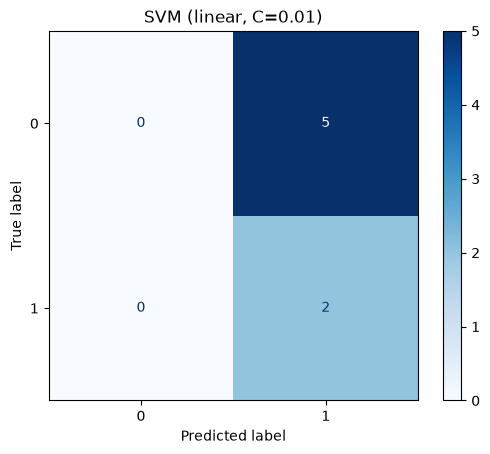

[[0 5]
 [0 2]]
SVM C=0.01 | accuracy = 0.2857 | precision = 0.2857 | recall = 1.0 | F1 = 0.4444


In [7]:
from sklearn import svm
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

X_train = base_X
y_train = base_Y
X_test = [[0.1,0.3],[0.2,0.2],[0.3,0.3],[0.6,0.8],[0.9,0.7],[0.1,1],[0.2,0.9]]
y_test = [0,0,0,1,1,0,0]

svc = svm.SVC(kernel='linear', C=0.01).fit(X_train, y_train)
disp = ConfusionMatrixDisplay.from_estimator(svc, X_test, y_test, cmap=plt.cm.Blues)
plt.title('SVM (linear, C=0.01)')
plt.show()
print(disp.confusion_matrix)

def metrics(y_pred, name):
    print(name,
          '| accuracy =', round(accuracy_score(y_test, y_pred), 4),
          '| precision =', round(precision_score(y_test, y_pred, zero_division=0), 4),
          '| recall =', round(recall_score(y_test, y_pred, zero_division=0), 4),
          '| F1 =', round(f1_score(y_test, y_pred, zero_division=0), 4))

metrics(svc.predict(X_test), 'SVM C=0.01')

接著是題目要求的**決策樹**指標與混淆矩陣。
**預期**:`[[5, 0], [0, 2]]`,accuracy / precision / recall / F1 全部 1.0。**這張圖也截圖附進貼文。**

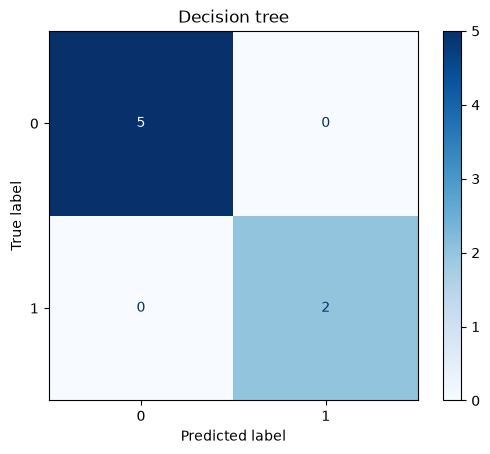

[[5 0]
 [0 2]]
Decision tree | accuracy = 1.0 | precision = 1.0 | recall = 1.0 | F1 = 1.0


In [8]:
dt = tree.DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
disp = ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Decision tree')
plt.show()
print(disp.confusion_matrix)
metrics(dt.predict(X_test), 'Decision tree')

最後的對照實驗:同一個 SVM,只把 `C` 從 0.01 改成 1。
**預期**:混淆矩陣變 `[[5, 0], [0, 2]]`、指標全 1.0——證明示範版表現差是**超參數**問題,不是演算法優劣。貼文的發現 1 就是靠這格。

In [9]:
svc1 = svm.SVC(kernel='linear', C=1).fit(X_train, y_train)
print(confusion_matrix(y_test, svc1.predict(X_test)))
metrics(svc1.predict(X_test), 'SVM C=1')

[[5 0]
 [0 2]]
SVM C=1 | accuracy = 1.0 | precision = 1.0 | recall = 1.0 | F1 = 1.0


---
跑完後:
1. 對照每格上方的「預期」,數字應完全一致(都固定了 `random_state=0`,無隨機性)。
2. 3.2.1 評論框貼文 + 3.2.4 討論區貼文的全文在 `notes/Unit2-3_內嵌練習擬答.md` §7 與 §9,兩張混淆矩陣圖記得截圖附上。
3. 本 notebook 全部跑完、帶輸出的樣子,就是 A2a 要求的「非空、已執行、有結果的 .ipynb」的格式預演。